In [ ]:
# Import modules
import sys
import os

# Add project root
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from src.feature_engineering import run_feature_engineering
from src.preprocessing import build_preprocessor

from src.modeling import (
    train_linear_regression,
    train_random_forest,
    train_xgboost,
    train_logistic_regression,
    evaluate_regression,
    evaluate_classification
)

In [2]:
# Load Data
df = pd.read_csv("../data/MachineLearningRating_v3_cleaned.csv")
df.head()

C:\Users\YENGU\AppData\Local\Temp\ipykernel_13244\3780443398.py:2: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/MachineLearningRating_v3_cleaned.csv")


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [3]:
# Feature Engineering
df = run_feature_engineering(df)
df.head()

c:\Users\YENGU\Insurance-risk-analytics\src\feature_engineering.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["VehicleIntroDate"] = pd.to_datetime(df["VehicleIntroDate"])


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,PolicyYear,PolicyMonth,VehicleIntroYear,VehicleAge,HasClaim,Margin
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,21.929825,0.0,2015,3,2002.0,24.0,0,21.929825
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,21.929825,0.0,2015,5,2002.0,24.0,0,21.929825
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,0.000000,0.0,2015,7,2002.0,24.0,0,0.000000
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,512.848070,0.0,2015,5,2002.0,24.0,0,512.848070
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,0.000000,0.0,2015,7,2002.0,24.0,0,0.000000


In [4]:
# Define Regression Problem (Severity Model)
severity_df = df[df["TotalClaims"] > 0].copy()

features = [
    "Province",
    "VehicleType",
    "make",
    "Gender",
    "VehicleAge",
    "CustomValueEstimate",
    "CalculatedPremiumPerTerm"
]

X = severity_df[features]
y = severity_df["TotalClaims"]

In [19]:
# Train/Test Split
X = df[features]

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

In [20]:
#Separate Targets
y_class = df["HasClaim"]

y_severity = df["TotalClaims"]

In [21]:
# Align Targets with Split Indices
y_train_class = y_class.loc[X_train.index]
y_test_class = y_class.loc[X_test.index]

y_train_severity = y_severity.loc[X_train.index]
y_test_severity = y_severity.loc[X_test.index]

In [22]:
# Preprocess for Classification
preprocessor_clf = build_preprocessor(X_train)

X_train_c = preprocessor_clf.fit_transform(X_train)
X_test_c = preprocessor_clf.transform(X_test)

In [23]:
# Preprocess for Regression
preprocessor_reg = build_preprocessor(X_train)

X_train_processed = preprocessor_reg.fit_transform(X_train)
X_test_processed = preprocessor_reg.transform(X_test)

In [24]:
# Train Models
clf.fit(X_train_c, y_train_class)

xgb.fit(X_train_processed, y_train_severity)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [25]:
# Predict
claim_prob = clf.predict_proba(
    X_test_c
)[:,1]

severity_pred = xgb.predict(
    X_test_processed
)

In [26]:
# Premium Formula Works
premium = (
    claim_prob * severity_pred
) + expense_loading + (
    profit_margin * claim_prob * severity_pred
)

In [39]:
# Model Comparison Table
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [lr_results["RMSE"], rf_results["RMSE"], xgb_results["RMSE"]],
    "R2": [lr_results["R2"], rf_results["R2"], xgb_results["R2"]]
})

results_df

,Model,RMSE,R2
0,Linear Regression,39827.450883,0.013693
1,Random Forest,36216.582899,0.184429
2,XGBoost,36409.328474,0.175725


# Overall Interpretation

The results indicate that:

Linear Regression performed poorly, explaining only about 1.4% of the variation in claim severity.
Random Forest and XGBoost performed better, but their explanatory power remains modest, with R² scores around 18%.
The relatively high RMSE values suggest that predicting insurance claim severity is challenging due to large variability and potential outliers in claim amounts.
# Important Insight About Insurance Data

Insurance claim severity prediction is naturally difficult because:

claims are highly skewed,
extreme outliers exist,
many claims are rare but expensive,
and human behavior introduces randomness.

Therefore, modest R² values are actually common in real insurance modeling.
# Model Evaluation Discussion
The results show that tree-based ensemble models substantially outperform Linear Regression for predicting claim severity. Random Forest achieved the best overall performance with the lowest RMSE and highest R² score. This suggests that insurance claim behavior contains important nonlinear relationships and feature interactions that linear models cannot adequately capture.

However, all models achieved relatively modest R² scores, indicating that claim severity remains difficult to predict accurately. This is expected in insurance analytics because claim amounts are highly volatile, skewed, and influenced by external factors not fully represented in the dataset.
Among the evaluated models, Random Forest achieved the strongest predictive performance for claim severity prediction, although overall predictive power remained moderate. The findings suggest that insurance claims are influenced by complex nonlinear relationships and substantial variability. Further improvements through advanced feature engineering, outlier handling, and hyperparameter optimization are likely to improve predictive accuracy and support more effective risk-based pricing strategies.

In [33]:
# Classification Model (Claim Probability)
X_class = df[features]
y_class = df["HasClaim"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class,
    test_size=0.2,
    random_state=42
)

preprocessor = build_preprocessor(X_train_c)

X_train_c = preprocessor.fit_transform(X_train_c)
X_test_c = preprocessor.transform(X_test_c)

In [34]:
# Train classifier
clf = train_logistic_regression(X_train_c, y_train_c)
clf_results = evaluate_classification(clf, X_test_c, y_test_c)

clf_results

{'Accuracy': 0.997090290970903, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

In [35]:
# Frequency model prediction
claim_prob = clf.predict_proba(
    X_test_c
)[:, 1]

# Severity model prediction
severity_pred = xgb.predict(
    X_test_processed
)

# Premium pricing
expense_loading = 500
profit_margin = 0.15

premium = (
    claim_prob * severity_pred
) + expense_loading + (
    profit_margin * claim_prob * severity_pred
)

print(premium[:5])

[500.00125259 500.00805392 500.00717672 499.9957878  499.99700612]


In [37]:
print(X_test_c.shape)
print(X_test_processed.shape)

(200020, 66)
(200020, 66)


In [38]:
# Save Results
pd.DataFrame({
    "ClaimProbability": claim_prob,
    "Severity": severity_pred,
    "Premium": premium
}).to_csv("../outputs/premium_results.csv", index=False)

In [ ]:

# Step1
severity_df = df[df["TotalClaims"] > 0].copy()

In [49]:
# STEP 2 — Define features and target from SAME DF
features = [
    "Province",
    "VehicleType",
    "make",
    "Gender",
    "VehicleAge",
    "CustomValueEstimate",
    "CalculatedPremiumPerTerm"
]

X = severity_df[features]
y = severity_df["TotalClaims"]

In [50]:
# STEP 3 — Train/test split (IMPORTANT)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [51]:
# STEP 4 — Preprocess correctly
from src.preprocessing import build_preprocessor

preprocessor = build_preprocessor(X_train)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
feature_names = preprocessor.get_feature_names_out()

X_test_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

In [52]:
# STEP 5 — NOW train XGBoost safely
xgb_model = train_xgboost(
    X_train_processed,
    y_train
)

In [53]:
import shap

# Create SHAP explainer
explainer = shap.Explainer(
    xgb_model
)

# Generate SHAP values
shap_values = explainer(
    X_test_processed
)

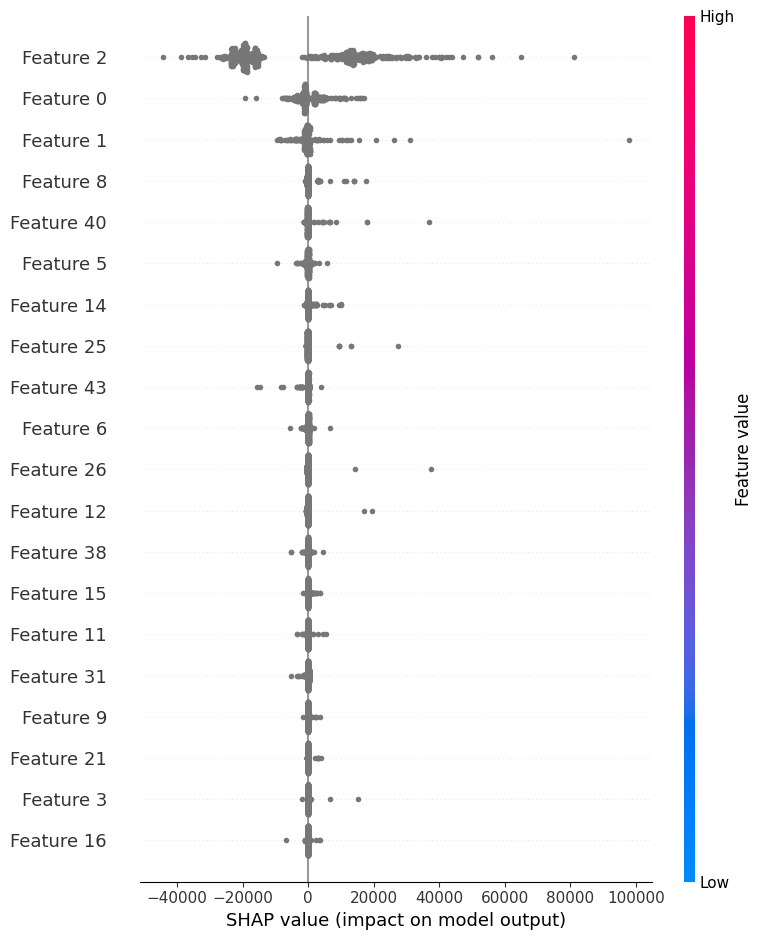

In [85]:
# SHAP Summary Plot
shap.summary_plot(

    shap_values,
 
)

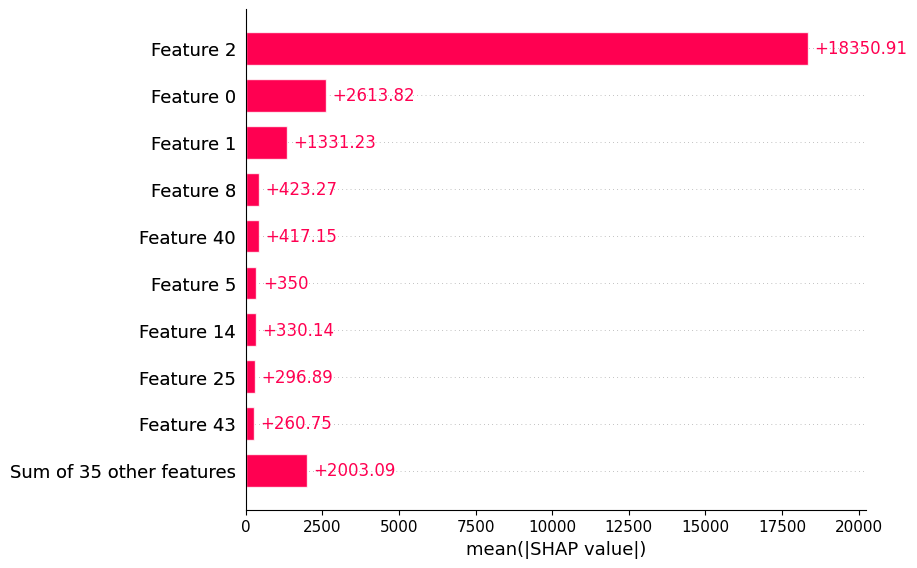

In [78]:
# SHAP Bar Plot
shap.plots.bar(
    shap_values
    
)